# Unemployment Analysis with Python


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/dineshkqryadav97gmail.com/Downloads/Unemployment in India.xls')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.shape

(768, 7)

In [4]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
# Checking missing values.
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
# Cheking missing values in percentage.
missing_percentage = (df.isnull().sum() / len(df))*100

In [8]:
missing_percentage

Region                                      3.645833
 Date                                       3.645833
 Frequency                                  3.645833
 Estimated Unemployment Rate (%)            3.645833
 Estimated Employed                         3.645833
 Estimated Labour Participation Rate (%)    3.645833
Area                                        3.645833
dtype: float64

In [9]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [10]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [11]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

# Handle the missing values.

In [12]:
# Display rows containing missing values
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [13]:
# Remove rows where all values are missing
df = df.dropna(how="all")

In [14]:
# Reset the index
df.reset_index(drop=True, inplace=True)

In [15]:
# Check the new shape
print("Shape after removing empty rows:", df.shape)


Shape after removing empty rows: (740, 7)


In [16]:
# Check missing values again
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [17]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [18]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [19]:
# Calculate the average unemployment rate for each region
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

# EDA ( Exploratory Data Analysis )

In [20]:
# Region-wise average unemployment rate

region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

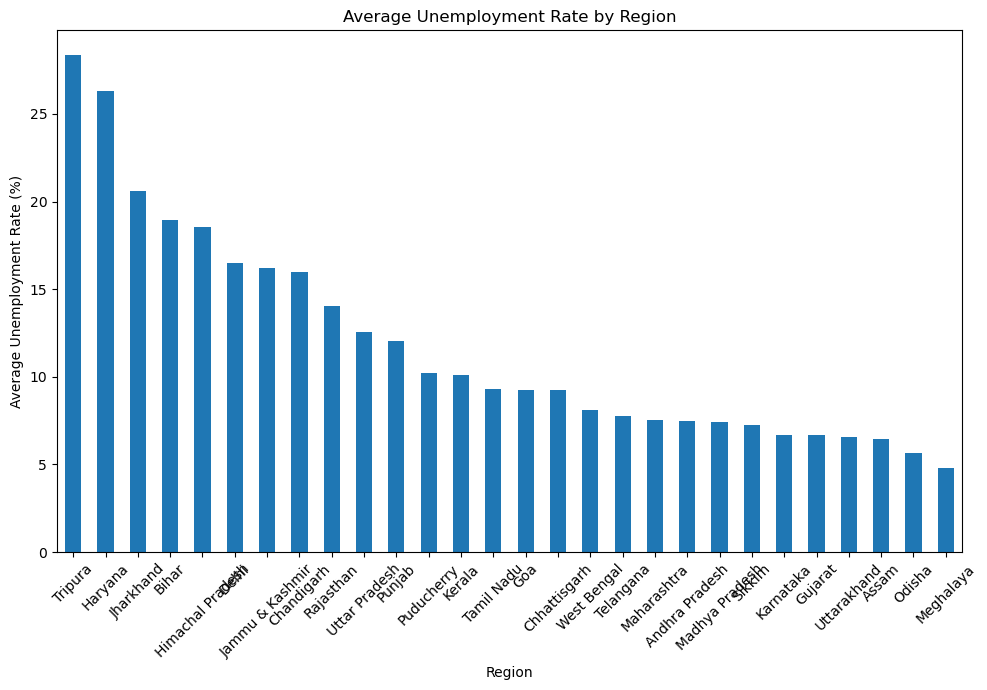

In [21]:
# Bar chart of average unemployment rate by region

plt.figure(figsize=(10, 7))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 ### Observation

### This chart shows the average unemployment rate across different regions.
### It helps us compare unemployment levels and identify the regions with relatively
### higher and lower average unemployment rates.

In [22]:
# Month-wise average unemployment rate

monthly_avg = df.groupby(df["Date"].dt.to_period("M"))[
    "Estimated Unemployment Rate (%)"
].mean()

monthly_avg

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

# Plot month-wise unemployment trend


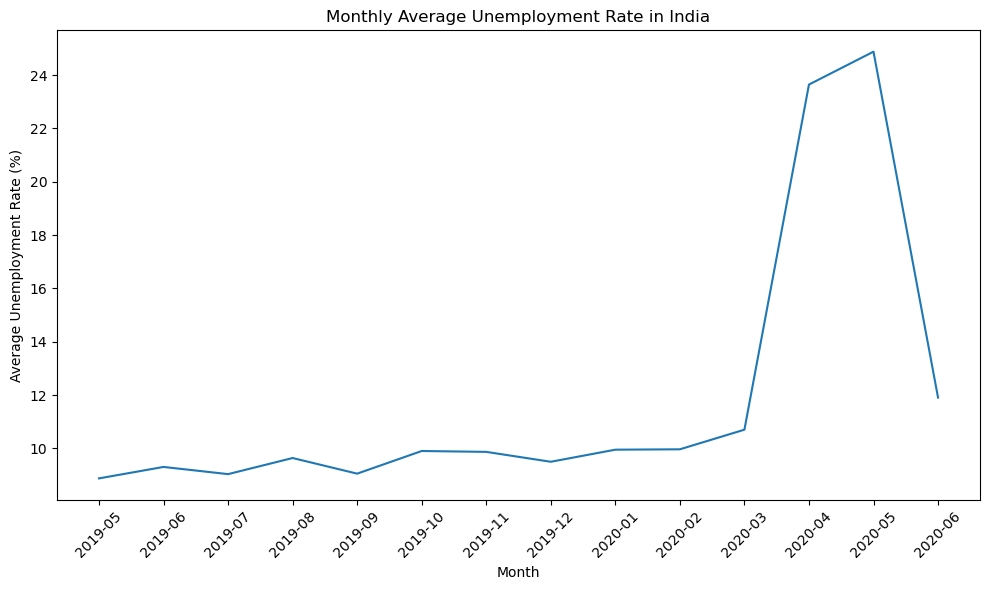

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_avg.index.astype(str), monthly_avg.values)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

### The line chart shows how the average unemployment rate changed month by month.
### It helps identify periods of increasing or decreasing unemployment and makes
### it easier to observe the overall trend over time.

In [24]:
# Select 3 regions for time-series comparison

selected_regions = ["Haryana", "Bihar", "Tripura"]

region_data = df[df["Region"].isin(selected_regions)]

region_data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
26,Bihar,2019-05-31,Monthly,9.27,24322330.0,39.75,Rural
27,Bihar,2019-06-30,Monthly,10.20,24097712.0,39.71,Rural
28,Bihar,2019-07-31,Monthly,13.44,23248875.0,39.66,Rural
29,Bihar,2019-08-31,Monthly,11.00,22260203.0,36.85,Rural
30,Bihar,2019-09-30,Monthly,8.87,23905700.0,38.57,Rural


# Plot unemployment rate over time for 3 regions

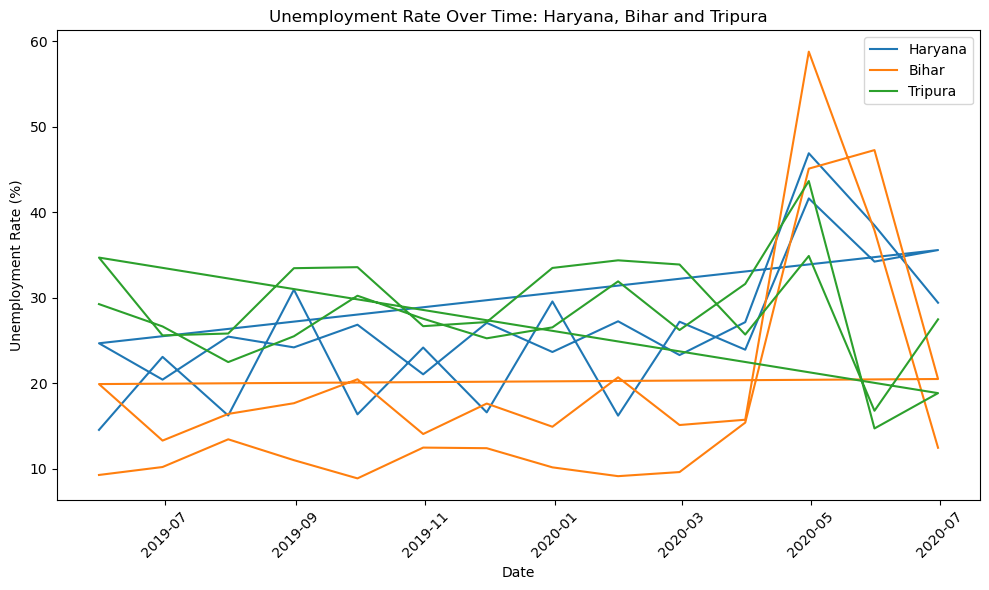

In [25]:
plt.figure(figsize=(10, 6))

for region in selected_regions:
    data = region_data[region_data["Region"] == region]
    plt.plot(
        data["Date"],
        data["Estimated Unemployment Rate (%)"],
        label=region
    )

plt.title("Unemployment Rate Over Time: Haryana, Bihar and Tripura")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

### The time-series comparison shows how unemployment rates changed over time in Haryana, Bihar, and Tripura.
### The three regions show different unemployment patterns, with a noticeable increase around April–May 2020.

In [26]:
# Top 10 regions with highest average unemployment rate

top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

# Plot top 10 regions

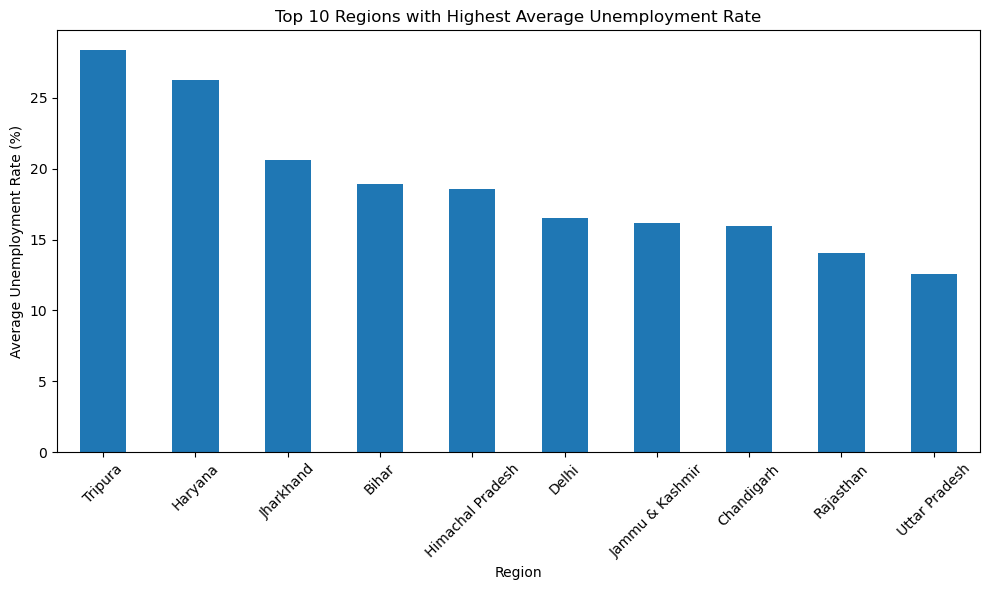

In [27]:
plt.figure(figsize=(10, 6))

top_10_regions.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation Heatmap

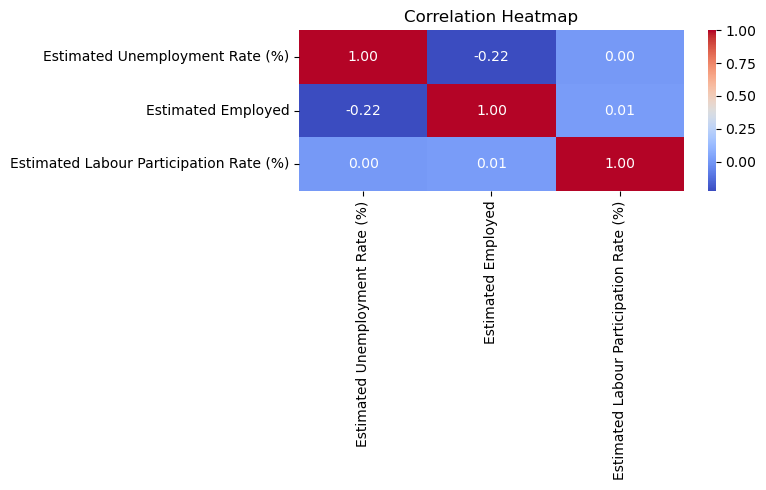

In [28]:
# Correlation between unemployment rate, employment and labour participation

correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Calculate Pre-COVID and Post-COVID averages

In [29]:
# Split data into Pre-COVID and Post-COVID periods

pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]



In [30]:
# Calculate average unemployment rate

pre_covid_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_covid_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average Unemployment Rate:",
      round(pre_covid_avg, 2), "%")

print("Post-COVID Average Unemployment Rate:",
      round(post_covid_avg, 2), "%")

Pre-COVID Average Unemployment Rate: 9.51 %
Post-COVID Average Unemployment Rate: 17.77 %


<BarContainer object of 2 artists>

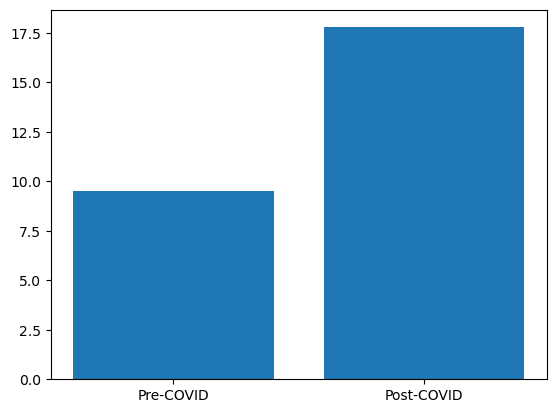

In [31]:
periods = ["Pre-COVID", "Post-COVID"]
average_rates = [pre_covid_avg, post_covid_avg]

plt.bar(periods, average_rates)


### Observation

### Unemployment increased from **9.51% pre-COVID to 17.77% post-COVID**
### showing a significant rise during the pandemic.


# Conclusion



### Tripura and Haryana have the **highest average unemploymentrates**
###  while Uttar Pradesh is among the lower rates in the top 10 regions.



### Bihar shows the highest variation in unemployment while Haryana and Tripura 
### also experienced noticeable changes during 2019–2020.



### Unemployment remained relatively stable in 2019 but increased sharply during 
### **April–May 2020** reflecting the impact of COVID-19.

#
# Thankyou.